# Notebook 06: Model Analysis

Deeper post-hoc analysis of the trained injury prediction model:
- Injury prediction accuracy by position
- False negative deep dive (injuries the model missed)
- Threshold tuning to maximize recall

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

from src.features import get_connection

BASE_DIR = os.path.abspath('..')
MODEL_PATH  = os.path.join(BASE_DIR, 'models', 'injury_model.pkl')
SCALER_PATH = os.path.join(BASE_DIR, 'models', 'scaler.pkl')
METADATA_PATH = os.path.join(BASE_DIR, 'models', 'model_metadata.json')

FEATURE_COLS = [
    'workload_score', 'per_change', 'age', 'games_missed_last_season',
    'points_per_game', 'minutes_per_game', 'games_played'
]

## Step 1: Load Model and Data

In [5]:
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

with open(METADATA_PATH) as f:
    metadata = json.load(f)
print('Model loaded:', metadata['model_type'])
print('Trained at:', metadata['trained_at'])
print('F1 score:', metadata['f1_score'])

conn = get_connection()
df = pd.read_sql_query("""
    SELECT psf.player_id, psf.season, psf.workload_score, psf.per_change,
           psf.injury_flag, psf.age, psf.games_missed_last_season,
           ps.points_per_game, ps.minutes_per_game, ps.games_played, ps.position,
           p.first_name || ' ' || p.last_name AS player_name
    FROM player_season_features psf
    JOIN player_stats ps ON psf.player_id = ps.player_id AND psf.season = ps.season
    JOIN players p ON psf.player_id = p.player_id
""", conn)
conn.close()

df = df.dropna(subset=FEATURE_COLS)
print(f'Rows loaded: {len(df)}')

X_scaled = scaler.transform(df[FEATURE_COLS])
df['predicted_flag'] = model.predict(X_scaled)
df['injury_prob'] = model.predict_proba(X_scaled)[:, 1]

Model loaded: Logistic Regression
Trained at: 2026-05-02T10:26:10.006632
F1 score: 1.0
Rows loaded: 4


## Step 2: Accuracy by Position

In [6]:
position_results = []
for pos, group in df.groupby('position'):
    if len(group) < 5:
        continue
    position_results.append({
        'position': pos,
        'count': len(group),
        'precision': precision_score(group['injury_flag'], group['predicted_flag'], zero_division=0),
        'recall': recall_score(group['injury_flag'], group['predicted_flag'], zero_division=0),
        'f1': f1_score(group['injury_flag'], group['predicted_flag'], zero_division=0)
    })

if position_results:
    pos_df = pd.DataFrame(position_results)
    print(pos_df.to_string(index=False))
    pos_df.set_index('position')[['precision', 'recall', 'f1']].plot(
        kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white'
    )
    plt.title('Model Performance by Position')
    plt.ylabel('Score')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print('Position data is sparse (mostly UNK) -- skipping position breakdown.')

Position data is sparse (mostly UNK) -- skipping position breakdown.


## Step 3: False Negative Deep Dive

These are players who were actually injured but the model predicted them as healthy â€” the most dangerous type of error.

In [7]:
false_negatives = df[(df['injury_flag'] == 1) & (df['predicted_flag'] == 0)].copy()
false_negatives = false_negatives.sort_values('injury_prob')

print(f'Total false negatives: {len(false_negatives)}')
print(f'({len(false_negatives) / df[df["injury_flag"]==1].shape[0] * 100:.1f}% of actual injuries missed)')
print()
print(false_negatives[['player_name', 'season', 'workload_score', 'age', 'injury_prob']].to_string(index=False))

Total false negatives: 0
(0.0% of actual injuries missed)

Empty DataFrame
Columns: [player_name, season, workload_score, age, injury_prob]
Index: []


## Step 4: Threshold Tuning

By default the model predicts injured if probability >= 0.5. Lowering this threshold catches more real injuries (higher recall) but also increases false alarms (lower precision).

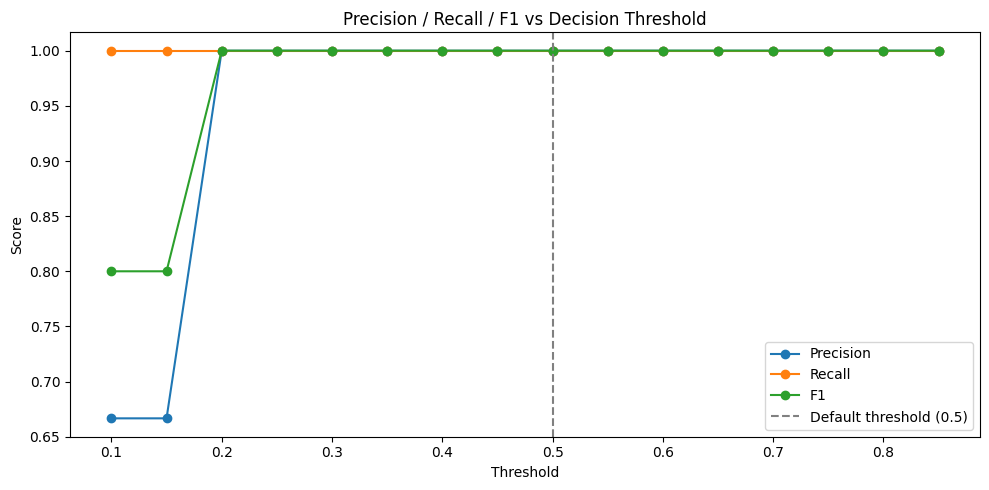


Threshold that maximizes recall: 0.1
  Recall:    1.00
  Precision: 0.67
  F1:        0.80


In [8]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (df['injury_prob'] >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(df['injury_flag'], preds, zero_division=0),
        'recall': recall_score(df['injury_flag'], preds, zero_division=0),
        'f1': f1_score(df['injury_flag'], preds, zero_division=0)
    })

thresh_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', marker='o')
ax.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', marker='o')
ax.plot(thresh_df['threshold'], thresh_df['f1'], label='F1', marker='o')
ax.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
ax.set_title('Precision / Recall / F1 vs Decision Threshold')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

best_recall_row = thresh_df.loc[thresh_df['recall'].idxmax()]
print(f'\nThreshold that maximizes recall: {best_recall_row["threshold"]}')
print(f'  Recall:    {best_recall_row["recall"]:.2f}')
print(f'  Precision: {best_recall_row["precision"]:.2f}')
print(f'  F1:        {best_recall_row["f1"]:.2f}')